# Naive Bayes Classifier from Scratch
by AI@UCI

** ENSURE YOU ARE RUNNING THIS IN AN ENVIRONMENT WITH THE REQUIRED PACKAGES **

## Introduction to Naive Bayes Classifier

The Naive Bayes Classifier is a probabilistic classification algorithm that:

- Uses Bayes' theorem with strong independence assumptions between features
- Calculates the probability of each class given the features
- Is fast, simple, and works well with small datasets
- Often performs surprisingly well despite the "naive" assumption

We'll implement:
- Gaussian Naive Bayes for continuous features
- Probability calculations using Bayes' theorem
- Classification based on maximum posterior probability


In [10]:
! pip install numpy pandas matplotlib


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, pi, exp


## Loading the Weather Dataset


In [12]:
# Load the weather dataset
WEATHER_CSV = "../datasets/bayes_weather_dataset.csv"
df = pd.read_csv(WEATHER_CSV)
df.head()


,outlook,temperature,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [13]:
# Convert categorical features to numeric
def encode_categorical(df):
    """Convert categorical columns to numeric."""
    df_encoded = df.copy()
    for col in df_encoded.columns:
        if df_encoded[col].dtype == 'object':
            df_encoded[col] = pd.Categorical(df_encoded[col]).codes
    return df_encoded

df_encoded = encode_categorical(df)
print("Encoded dataset:")
print(df_encoded.head())
print(f"\nDataset shape: {df_encoded.shape}")
print(f"Target classes: {df_encoded['play'].unique()}")


Encoded dataset:
   outlook  temperature  humidity  windy  play
0        2            1         0  False     0
1        2            1         0   True     0
2        0            1         0  False     1
3        1            2         0  False     1
4        1            0         1  False     1

Dataset shape: (14, 5)
Target classes: [0 1]


In [14]:
# Separate features and target
X = df_encoded.drop(columns=['play']).values
y = df_encoded['play'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", df_encoded.drop(columns=['play']).columns.tolist())


Features shape: (14, 4)
Target shape: (14,)
Feature names: ['outlook', 'temperature', 'humidity', 'windy']


## Naive Bayes Implementation


In [15]:
class GaussianNaiveBayes:
    def __init__(self):
        """Initialize Gaussian Naive Bayes Classifier."""
        self.classes = None
        self.class_priors = None
        self.means = None
        self.variances = None

    def fit(self, X, y):
        """Fit the Naive Bayes model."""
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]
        
        # Initialize arrays
        self.class_priors = np.zeros(n_classes)
        self.means = np.zeros((n_classes, n_features))
        self.variances = np.zeros((n_classes, n_features))
        
        # Calculate priors, means, and variances for each class
        for i, cls in enumerate(self.classes):
            mask = y == cls
            X_cls = X[mask]
            
            # Prior probability
            self.class_priors[i] = len(X_cls) / len(X)
            
            # Mean and variance for each feature
            self.means[i] = np.mean(X_cls, axis=0)
            self.variances[i] = np.var(X_cls, axis=0)

    def _gaussian_pdf(self, x, mean, var):
        """Calculate Gaussian probability density function."""
        if var == 0:
            return 1.0 if x == mean else 0.0
        return (1 / sqrt(2 * pi * var)) * exp(-((x - mean) ** 2) / (2 * var))

    def _predict_one(self, x):
        """Predict class for a single sample."""
        posteriors = []
        
        for i, cls in enumerate(self.classes):
            # Start with prior probability
            posterior = self.class_priors[i]
            
            # Multiply by likelihood for each feature
            for j in range(len(x)):
                likelihood = self._gaussian_pdf(x[j], self.means[i][j], self.variances[i][j])
                posterior *= likelihood
            
            posteriors.append(posterior)
        
        # Return class with highest posterior probability
        return self.classes[np.argmax(posteriors)]

    def predict(self, X):
        """Predict classes for multiple samples."""
        return np.array([self._predict_one(x) for x in X])

    def score(self, X, y):
        """Calculate accuracy score."""
        preds = self.predict(X)
        return float(np.mean(preds == y))


In [16]:
# Train-test split
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.7 * len(X))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 9 samples
Test set: 5 samples


In [17]:
# Train and test the Naive Bayes Classifier
nb_clf = GaussianNaiveBayes()
nb_clf.fit(X_train, y_train)

accuracy = nb_clf.score(X_test, y_test)
print(f"Test accuracy: {accuracy:.3f}")

# Display model parameters
print("\nModel parameters:")
print("Class priors:", nb_clf.class_priors)
print("Means:\n", nb_clf.means)
print("Variances:\n", nb_clf.variances)


Test accuracy: 0.800

Model parameters:
Class priors: [0.44444444 0.55555556]
Means:
 [[1.5  1.   0.25 0.75]
 [0.6  1.2  0.6  0.2 ]]
Variances:
 [[0.25   0.5    0.1875 0.1875]
 [0.64   0.56   0.24   0.16  ]]


Predictions vs Actual:
Sample 1: Predicted=Yes, Actual=Yes
Sample 2: Predicted=No, Actual=No
Sample 3: Predicted=No, Actual=Yes
Sample 4: Predicted=Yes, Actual=Yes
Sample 5: Predicted=Yes, Actual=Yes


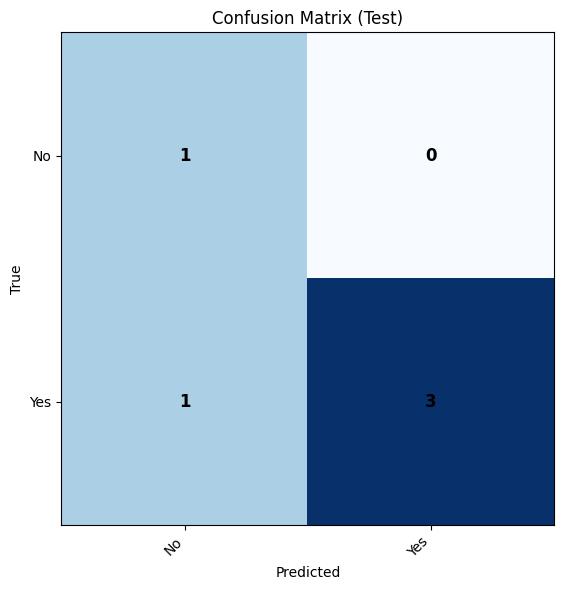

In [18]:
# Make predictions and show results
y_pred = nb_clf.predict(X_test)

print("Predictions vs Actual:")
for i in range(len(X_test)):
    actual = "Yes" if y_test[i] == 1 else "No"
    predicted = "Yes" if y_pred[i] == 1 else "No"
    print(f"Sample {i+1}: Predicted={predicted}, Actual={actual}")

# Calculate confusion matrix
from itertools import product

def plot_confusion_matrix(y_true, y_pred, labels):
    n = len(labels)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap='Blues')
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(ticks=np.arange(n), labels=labels, rotation=45, ha="right")
    plt.yticks(ticks=np.arange(n), labels=labels)
    for (i, j) in product(range(n), range(n)):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display confusion matrix
labels = ["No", "Yes"]
plot_confusion_matrix(y_test, y_pred, labels)


## Model Parameter Visualization


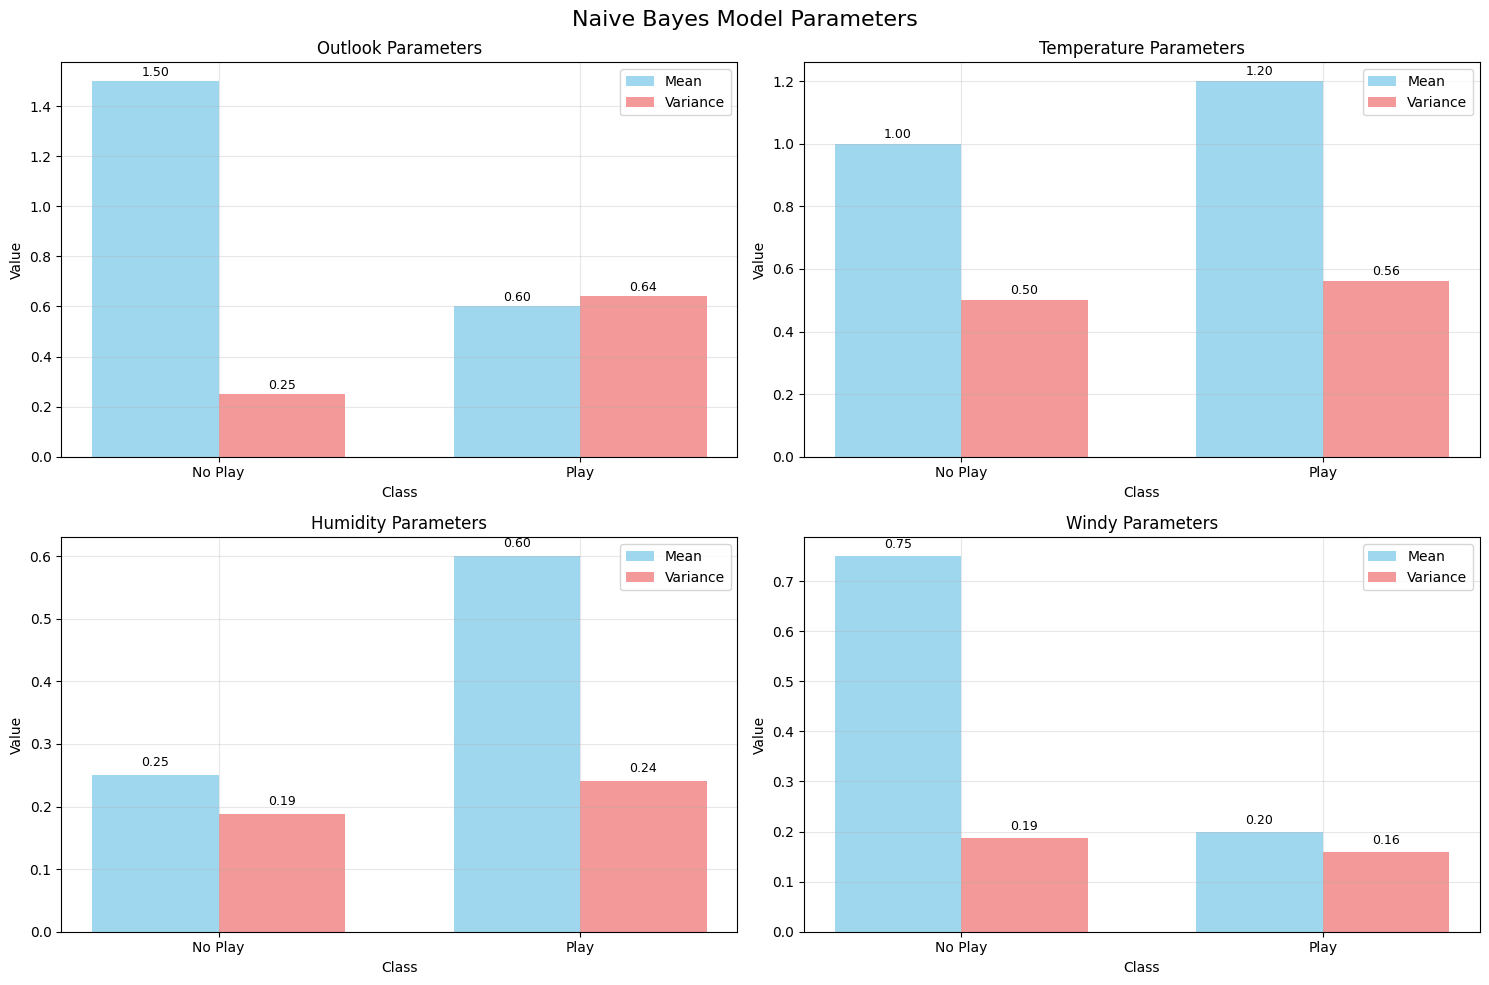

In [19]:
# Visualize the learned parameters
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Naive Bayes Model Parameters', fontsize=16)

feature_names = ['outlook', 'temperature', 'humidity', 'windy']
class_names = ['No Play', 'Play']

# Plot means for each feature
for i, feature in enumerate(feature_names):
    row = i // 2
    col = i % 2
    
    means = nb_clf.means[:, i]
    variances = nb_clf.variances[:, i]
    
    x = np.arange(len(class_names))
    width = 0.35
    
    bars1 = axes[row, col].bar(x - width/2, means, width, label='Mean', alpha=0.8, color='skyblue')
    bars2 = axes[row, col].bar(x + width/2, variances, width, label='Variance', alpha=0.8, color='lightcoral')
    
    axes[row, col].set_xlabel('Class')
    axes[row, col].set_ylabel('Value')
    axes[row, col].set_title(f'{feature.title()} Parameters')
    axes[row, col].set_xticks(x)
    axes[row, col].set_xticklabels(class_names)
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    for bar in bars2:
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


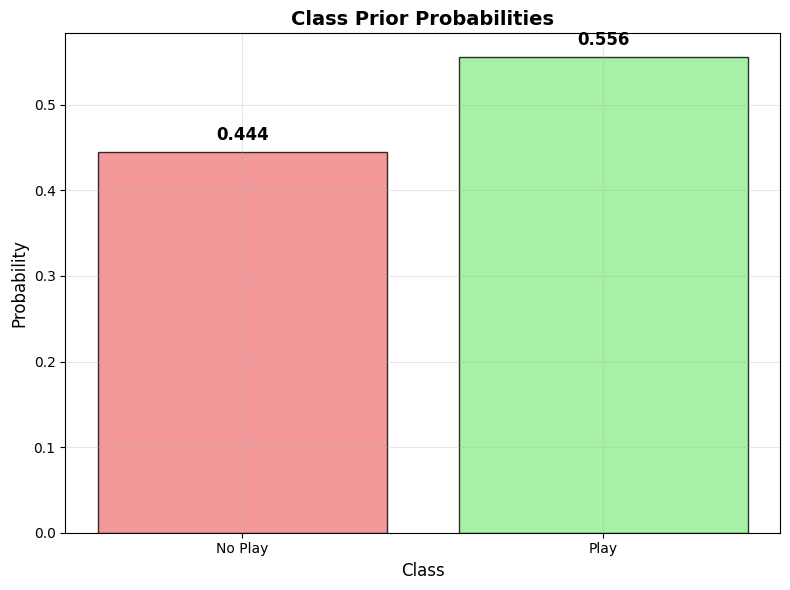

Class priors: {'No Play': 0.4444444444444444, 'Play': 0.5555555555555556}


In [20]:
# Visualize class priors
plt.figure(figsize=(8, 6))
class_names = ['No Play', 'Play']
colors = ['lightcoral', 'lightgreen']

bars = plt.bar(class_names, nb_clf.class_priors, color=colors, alpha=0.8, edgecolor='black')
plt.title('Class Prior Probabilities', fontsize=14, fontweight='bold')
plt.ylabel('Probability', fontsize=12)
plt.xlabel('Class', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Class priors: {dict(zip(class_names, nb_clf.class_priors))}")


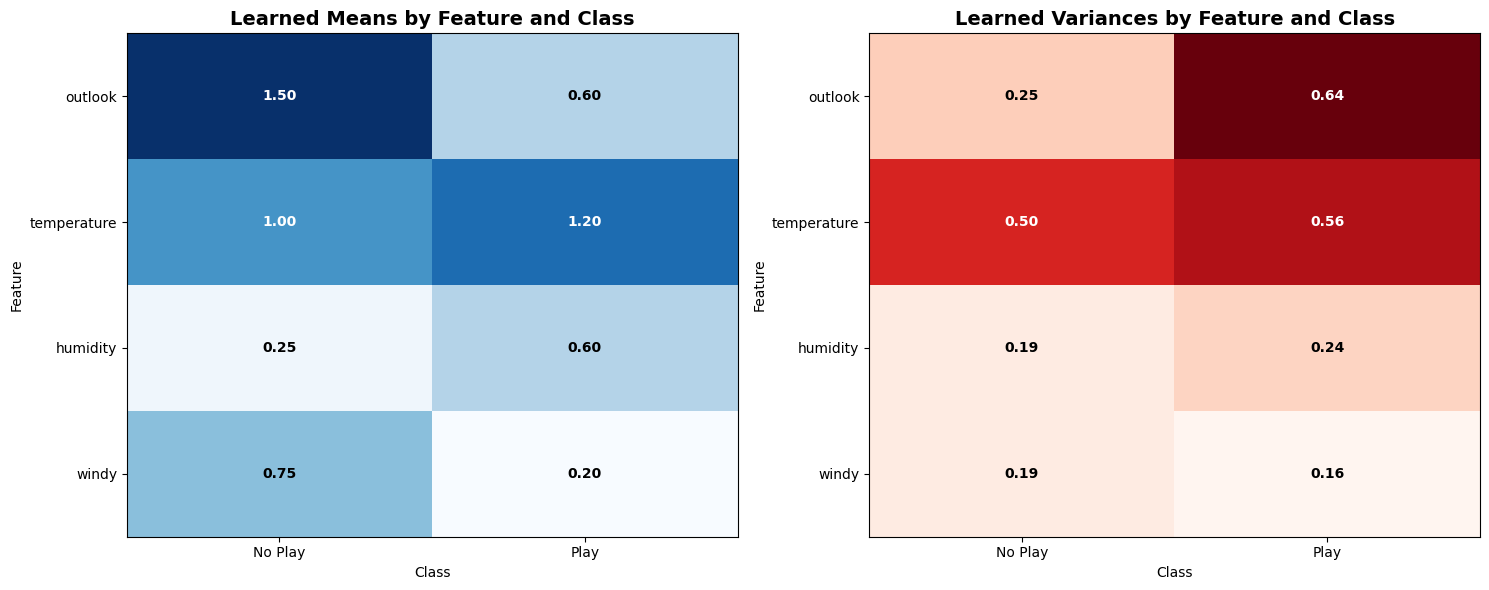

In [21]:
# Create a heatmap of the learned parameters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Means heatmap
means_data = nb_clf.means.T  # Transpose to have features as rows
im1 = ax1.imshow(means_data, cmap='Blues', aspect='auto')
ax1.set_title('Learned Means by Feature and Class', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class')
ax1.set_ylabel('Feature')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['No Play', 'Play'])
ax1.set_yticks(range(len(feature_names)))
ax1.set_yticklabels(feature_names)

# Add text annotations for means
for i in range(len(feature_names)):
    for j in range(len(class_names)):
        text = ax1.text(j, i, f'{means_data[i, j]:.2f}',
                       ha="center", va="center", color="white" if means_data[i, j] > means_data.max()/2 else "black",
                       fontweight='bold')

# Variances heatmap
variances_data = nb_clf.variances.T  # Transpose to have features as rows
im2 = ax2.imshow(variances_data, cmap='Reds', aspect='auto')
ax2.set_title('Learned Variances by Feature and Class', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class')
ax2.set_ylabel('Feature')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['No Play', 'Play'])
ax2.set_yticks(range(len(feature_names)))
ax2.set_yticklabels(feature_names)

# Add text annotations for variances
for i in range(len(feature_names)):
    for j in range(len(class_names)):
        text = ax2.text(j, i, f'{variances_data[i, j]:.2f}',
                       ha="center", va="center", color="white" if variances_data[i, j] > variances_data.max()/2 else "black",
                       fontweight='bold')

plt.tight_layout()
plt.show()


## Summary

In this notebook, we successfully implemented the Gaussian Naive Bayes Classifier from scratch and applied it to the weather dataset. Key takeaways:

1. **Naive Bayes is probabilistic** - it calculates class probabilities using Bayes' theorem
2. **"Naive" assumption** - features are assumed to be independent (often not true in practice)
3. **Gaussian assumption** - continuous features are assumed to follow normal distributions
4. **Fast and simple** - no complex optimization, just probability calculations
5. **Works well with small datasets** - often performs surprisingly well despite assumptions

The implementation demonstrates how probabilistic classification works and shows the power of the Naive Bayes approach even with its simplifying assumptions.
